# DS1000 Adapter Verification v2 – Full Hallucination Pipeline (Windows Version)

Same as the basic Verify notebook (adapter-only code generation, baseline from CSV) but runs the **full hallucination pipeline** (AST, dynamic, lib_api, patch) per task and outputs a CSV with the same schema as `ds1000_pipeline_output.csv`. Windows-compatible; no quantization; GPU recommended (~6GB VRAM).

## 1. Setup

In [2]:
# Check GPU (optional; skip if no NVIDIA GPU)
import subprocess
try:
    subprocess.run(["nvidia-smi"], check=True)
except Exception as e:
    print("nvidia-smi not available:", e)
print('h')

Sat Mar 14 07:45:01 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.288.01             Driver Version: 535.288.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA RTX A4000               Off | 00000000:55:00.0 Off |                  Off |
| 41%   41C    P8              12W / 140W |     77MiB / 16376MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [3]:
!pip install -q transformers peft datasets torch accelerate tqdm pandas

## 2. Paths (local: baseline CSV + lora_adapters folder or zip)

In [5]:
import os
import zipfile

# Set paths for Jupyter (default: current working directory; set NOTEBOOK_DIR if needed)
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NOTEBOOK_DIR = os.getcwd()
BASELINE_CSV_PATH = os.path.join(NOTEBOOK_DIR, "ds1000_pipeline_output.csv")
ADAPTER_ZIP_OR_DIR = os.path.join(NOTEBOOK_DIR, "lora_adapters")

# If ADAPTER_ZIP_OR_DIR is a zip file, extract it; else use as adapter folder
if os.path.isfile(ADAPTER_ZIP_OR_DIR) and ADAPTER_ZIP_OR_DIR.lower().endswith(".zip"):
    ADAPTER_PATH = os.path.join(NOTEBOOK_DIR, "lora_adapters_extracted")
    os.makedirs(ADAPTER_PATH, exist_ok=True)
    with zipfile.ZipFile(ADAPTER_ZIP_OR_DIR, "r") as z:
        z.extractall(ADAPTER_PATH)
    subdirs = [d for d in os.listdir(ADAPTER_PATH) if os.path.isdir(os.path.join(ADAPTER_PATH, d))]
    if len(subdirs) == 1 and os.path.isfile(os.path.join(ADAPTER_PATH, subdirs[0], "adapter_config.json")):
        ADAPTER_PATH = os.path.join(ADAPTER_PATH, subdirs[0])
else:
    ADAPTER_PATH = ADAPTER_ZIP_OR_DIR
    if os.path.isdir(ADAPTER_PATH):
        subdirs = [d for d in os.listdir(ADAPTER_PATH) if os.path.isdir(os.path.join(ADAPTER_PATH, d))]
        if len(subdirs) == 1 and os.path.isfile(os.path.join(ADAPTER_PATH, subdirs[0], "adapter_config.json")):
            ADAPTER_PATH = os.path.join(ADAPTER_PATH, subdirs[0])

print(f"Baseline CSV: {BASELINE_CSV_PATH}")
print(f"Adapters at: {ADAPTER_PATH}")

Baseline CSV: /home/jovyan/FED/DS1000/ds1000_pipeline_output.csv
Adapters at: /home/jovyan/FED/DS1000/lora_adapters


In [7]:
!cd loara_adapters

/usr/bin/sh: 1: cd: can't cd to loara_adapters


In [6]:
!ls

SFT_LoRA_Adapters.ipynb			ds1000_pipeline_output.csv
SFT_LoRA_Adapters_Windows.ipynb		final_dataset_v2.csv
Verify_DS1000_Adapter_Colab_v2.ipynb	lora_adapters_1
Verify_DS1000_Adapter_Windows.ipynb	sft_ds1000_output
Verify_DS1000_Adapter_Windows_v2.ipynb	sft_ds1000_output_1
ds1000_adapter_pipeline_output.csv


## 3. Load DS1000

In [8]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("xlangai/DS-1000")
df = pd.DataFrame(ds["test"])
df["task_id"] = [f"DS{str(i).zfill(4)}" for i in range(len(df))]
df["prompt_2"] = df["prompt"].astype(str).str.split("A:", n=1).str[0].str.strip()
print(f"DS1000 tasks: {len(df)}")

DS1000 tasks: 1000


## 4. Load baseline from CSV (optional)

In [9]:
# Load DS1000 ids from the generated 25% test split CSV (baseline + evaluation must match)
TEST_CSV_PATH = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "final_dataset_v2_test.csv"))
df_test = pd.read_csv(TEST_CSV_PATH)
if "dataset" in df_test.columns:
    df_test = df_test[df_test["dataset"].astype(str).str.lower().eq("ds1000")].copy()
test_task_ids = df_test["task_id"].astype(str).tolist()

# Baseline pipeline outputs (filter down to the same task ids)
df_baseline = pd.read_csv(BASELINE_CSV_PATH)
df_baseline["task_id"] = df_baseline["task_id"].astype(str)
id_to_row = df_baseline.set_index("task_id").to_dict("index")
ordered_rows = []
for tid in test_task_ids:
    if tid in id_to_row:
        ordered_rows.append({**id_to_row[tid], "task_id": tid})
df_baseline = pd.DataFrame(ordered_rows)

passed_baseline = (df_baseline["status"] == "passed").sum()
total_baseline = len(df_baseline)
pass_rate_baseline = passed_baseline / total_baseline if total_baseline else 0
print(f"Baseline (from CSV, test-split ids): {passed_baseline}/{total_baseline} passed, pass@1 = {pass_rate_baseline:.2%}")

Baseline (from CSV): 181/1000 passed, pass@1 = 18.10%


## 4b. Use same task set as baseline (fair comparison)

So that "After SFT" is evaluated on the **same tasks** as "Before SFT", we restrict `df` to the task_ids in your baseline CSV (same order). Adapter run will then use the same number of tasks (e.g. 327).

In [10]:
# Restrict to task_ids in baseline and preserve baseline order (same N for fair comparison)
df_baseline["task_id"] = df_baseline["task_id"].astype(str)
id_to_row = df.set_index("task_id").to_dict("index")
ordered_rows = []
for _, base_row in df_baseline.iterrows():
    tid = base_row["task_id"]
    if tid in id_to_row:
        ordered_rows.append({**id_to_row[tid], "task_id": tid})
if ordered_rows:
    df = pd.DataFrame(ordered_rows)
print(f"Adapter run will use same task set as baseline: {len(df)} tasks (baseline had {total_baseline})")
if len(df) < total_baseline:
    print(f"  Note: {total_baseline - len(df)} baseline rows had task_ids not in the loaded HF dataset.")
print(len(df))

Adapter run will use same task set as baseline: 1000 tasks (baseline had 1000)
1000


## 5. Generation helpers

In [11]:
import re

def construct_prompt_humaneval(docstring_prompt):
    system_message = (
        "You are an expert Python developer. Your task is to complete the function "
        "provided by the user. Follow the docstring exactly. "
        "Provide your output ONLY as a single Python code block starting with ```python."
    )
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": f"Complete this Python function:\n{docstring_prompt}"}
    ]
    return messages

def extract_only_exec_context_wi(code_context):
    if code_context is None or not str(code_context).strip():
        return "import pandas as pd\nimport numpy as np"
    pattern = r'exec_context = r"""(.*?)"""'
    match = re.search(pattern, str(code_context), re.DOTALL)
    return match.group(1).strip() if match else "import pandas as pd\nimport numpy as np"

def contruct_prompt_ds1k_v4(raw_prompt, exec_context_snippet):
    system_message = (
        "You are a Python data scientist. You write concise, correct Python code for data manipulation. "
        "You prefer direct, vectorized solutions over complex logic. "
        "Provide your output ONLY as a single Python code block starting with ```python."
    )
    user_message = (
        "You are given a Python code snippet with a placeholder [insert]. Your code will be INSERTED at that position.\n\n"
        "===== EXISTING CODE =====\n" + exec_context_snippet + "\n\n"
        "===== TASK =====\n" + raw_prompt + "\n\n"
        "===== OUTPUT =====\nReturn ONLY raw Python code.\n"
    )
    return [{"role": "system", "content": system_message}, {"role": "user", "content": user_message}]

def extract_python_code_humaneval(text):
    pattern = r"```(?:python)?\n?(.*?)```"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return text.strip()

## 6. Hallucination pipeline (DS1000, self-contained)

In [12]:
import ast
import json
import re
import threading
import traceback
from typing import Any, Dict, List, Tuple, Optional

TIMEOUT_SECONDS = 10

def execute_with_timeout(func, args, timeout=TIMEOUT_SECONDS):
    result_container = {"result": None, "exception": None, "traceback": None}
    def wrapper():
        try:
            result_container["result"] = func(*args)
        except Exception as e:
            result_container["exception"] = e
            result_container["traceback"] = traceback.format_exc()
    thread = threading.Thread(target=wrapper)
    thread.daemon = True
    thread.start()
    thread.join(timeout=timeout)
    if thread.is_alive():
        gen_code = args[0] if args else ""
        return {"status": "failed", "error_type": "TimeoutError", "error_message": "Execution exceeded timeout", "line_number": "", "test_case": "", "testcase_output": "", "generated_code": gen_code}
    if result_container["exception"] is not None:
        e = result_container["exception"]
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = result_container["traceback"] or ""
        line_num = "" if is_assertion_error else (extract_syntax_error_line(str(e)) if is_syntax_error else (min((f.lineno for f in tb if '<string>' in f.filename), default="") if [f for f in tb if '<string>' in f.filename] else ""))
        gen_code = args[0] if args else ""
        return {"status": "failed", "error_type": type(e).__name__, "error_message": str(e), "line_number": str(line_num) if line_num else "", "test_case": "", "testcase_output": full_traceback if is_assertion_error else "", "generated_code": gen_code}
    if result_container["result"] is not None:
        return result_container["result"]
    gen_code = args[0] if args else ""
    return {"status": "failed", "error_type": "UnknownError", "error_message": "No result returned", "line_number": "", "test_case": "", "testcase_output": "", "generated_code": gen_code}

def extract_syntax_error_line(error_message: str) -> str:
    match = re.search(r'\(<string>,\s*line\s+(\d+)\)', error_message)
    return match.group(1) if match else ""

def serialize_value(value: Any, max_length: int = 500) -> str:
    try:
        if value is None:
            return "None"
        if isinstance(value, (dict, list, tuple)):
            result = str(value)
        else:
            result = str(value)
        return result[:max_length] + "...[truncated]" if len(result) > max_length else result
    except Exception as e:
        return f"<Serialization Error: {str(e)}>"

def extract_ds1000_test_cases(generated_code: str, code_context: str) -> List[List[str]]:
    test_cases_data = []
    try:
        test_env = {}
        exec(code_context, test_env)
        if 'generate_test_case' not in test_env:
            return []
        for test_id in range(1, 10):
            try:
                test_input, expected_result = test_env['generate_test_case'](test_id)
                exec_env = {'test_input': test_input}
                try:
                    exec(generated_code, exec_env)
                    actual_result = exec_env.get('result', '<No result variable>')
                except Exception as exec_error:
                    actual_result = f"<Execution Error: {str(exec_error)}>"
                input_str = serialize_value(test_input)
                expected_str = serialize_value(expected_result)
                actual_str = serialize_value(actual_result)
                test_cases_data.append([input_str, expected_str, actual_str])
            except Exception:
                break
    except Exception:
        pass
    return test_cases_data

def execute_ds1000_test_inner(generated_code: str, code_context: str) -> Dict[str, Any]:
    test_env = {}
    line_offset = 0
    try:
        exec(code_context, test_env)
        exec_ctx = test_env.get('exec_context', '')
        if exec_ctx and '[insert]' in exec_ctx:
            line_offset = exec_ctx.split('[insert]')[0].count(chr(10))
        test_env['test_execution'](generated_code)
        return {"status": "passed", "error_type": "", "error_message": "", "line_number": "", "test_case": "", "testcase_output": "", "generated_code": generated_code}
    except Exception as e:
        is_assertion_error = isinstance(e, AssertionError)
        is_syntax_error = isinstance(e, SyntaxError)
        tb = traceback.extract_tb(e.__traceback__)
        full_traceback = traceback.format_exc()
        line_num = "" if is_assertion_error else (extract_syntax_error_line(str(e)) if is_syntax_error else "")
        if line_num and line_offset:
            line_num = str(max(1, int(line_num) - line_offset))
        if not line_num and not is_assertion_error and not is_syntax_error:
            string_frames = [f for f in tb if '<string>' in f.filename]
            if string_frames:
                raw_line = string_frames[-1].lineno
                line_num = str(max(1, raw_line - line_offset)) if raw_line else ""
        test_case_data = extract_ds1000_test_cases(generated_code, code_context)
        test_case_json = json.dumps(test_case_data) if test_case_data else ""
        return {"status": "failed", "error_type": type(e).__name__, "error_message": str(e), "line_number": str(line_num) if line_num else "", "test_case": test_case_json, "testcase_output": full_traceback if is_assertion_error else "", "generated_code": generated_code}

def execute_ds1000_test(generated_code: str, code_context: str) -> Dict[str, Any]:
    return execute_with_timeout(execute_ds1000_test_inner, (generated_code, code_context))

def run_dynamic_driver_dynamic_analysis(row, dataset_type: str, task_id: str, generated_code: str):
    if dataset_type == "ds1000":
        code_context = str(row.get("code_context", ""))
        return execute_ds1000_test(generated_code, code_context)
    return {"status": "failed", "error_type": "UnknownDataset", "error_message": f"Unsupported: {dataset_type}", "line_number": "", "test_case": "", "testcase_output": "", "generated_code": generated_code}

print("Pipeline: timeout, execute_ds1000_test, run_dynamic_driver (DS1000) defined.")

Pipeline: timeout, execute_ds1000_test, run_dynamic_driver (DS1000) defined.


In [13]:
import importlib

class StructuralViolationVisitor(ast.NodeVisitor):
    def __init__(self):
        self.errors = []
        self.in_function = 0
        self.in_loop = 0
    def _record(self, error_type: str, node: ast.AST):
        start = getattr(node, "lineno", None)
        end = getattr(node, "end_lineno", start)
        col = getattr(node, "col_offset", None)
        if start:
            self.errors.append({"type": error_type, "start_line": start, "end_line": end if end else start, "col_offset": col, "message": f"{error_type} detected"})
    def visit_FunctionDef(self, node):
        self.in_function += 1
        self.generic_visit(node)
        self.in_function -= 1
    def visit_AsyncFunctionDef(self, node):
        self.in_function += 1
        self.generic_visit(node)
        self.in_function -= 1
    def visit_For(self, node):
        self.in_loop += 1
        self.generic_visit(node)
        self.in_loop -= 1
    def visit_While(self, node):
        self.in_loop += 1
        self.generic_visit(node)
        self.in_loop -= 1
    def visit_Return(self, node):
        if self.in_function == 0:
            self._record("return_outside_function", node)
        self.generic_visit(node)
    def visit_Break(self, node):
        if self.in_loop == 0:
            self._record("break_outside_loop", node)
    def visit_Continue(self, node):
        if self.in_loop == 0:
            self._record("continue_outside_loop", node)

def analyze_ast_for_patch(code: str) -> Dict[str, Any]:
    result = {"ast_parsed": False, "ast_errors": []}
    try:
        tree = ast.parse(code)
        result["ast_parsed"] = True
        visitor = StructuralViolationVisitor()
        visitor.visit(tree)
        result["ast_errors"].extend(visitor.errors)
    except IndentationError as e:
        result["ast_errors"].append({"type": "IndentationError", "start_line": e.lineno, "end_line": e.lineno, "col_offset": e.offset, "message": e.msg})
    except SyntaxError as e:
        result["ast_errors"].append({"type": "SyntaxError", "start_line": e.lineno, "end_line": e.lineno, "col_offset": e.offset, "message": e.msg})
    return result

def safe_import_module(module_name):
    try:
        return importlib.import_module(module_name)
    except Exception:
        return None

class LibraryAPIVistor(ast.NodeVisitor):
    def __init__(self):
        self.imports = {}
        self.errors = []
    def visit_Import(self, node):
        for alias in node.names:
            module = safe_import_module(alias.name)
            if module is None:
                continue
            name = alias.asname or alias.name
            self.imports[name] = module
    def visit_ImportFrom(self, node):
        if node.module is None:
            return
        module = safe_import_module(node.module)
        if module is None:
            return
        for alias in node.names:
            if alias.name == "*":
                for attr in dir(module):
                    try:
                        self.imports[attr] = getattr(module, attr)
                    except Exception:
                        pass
                continue
            name = alias.asname or alias.name
            try:
                if hasattr(module, alias.name):
                    self.imports[name] = getattr(module, alias.name)
                else:
                    self.errors.append({"type": "name_error", "name": alias.name, "line": node.lineno})
            except Exception:
                pass
    def resolve_attribute_chain(self, node):
        parts = []
        while isinstance(node, ast.Attribute):
            parts.append(node.attr)
            node = node.value
        if isinstance(node, ast.Name):
            parts.append(node.id)
        else:
            return None
        return list(reversed(parts))
    def visit_Attribute(self, node):
        chain = self.resolve_attribute_chain(node)
        if chain is None:
            self.generic_visit(node)
            return
        base_name = chain[0]
        if base_name in self.imports:
            obj = self.imports[base_name]
            for attr in chain[1:]:
                try:
                    if hasattr(obj, attr):
                        obj = getattr(obj, attr)
                    else:
                        self.errors.append({"type": "attribute_error", "object": base_name, "attribute": attr, "line": node.lineno})
                        break
                except Exception:
                    break
        self.generic_visit(node)
    def visit_Call(self, node):
        if isinstance(node.func, ast.Attribute):
            chain = self.resolve_attribute_chain(node.func)
            if chain is not None and chain[0] in self.imports:
                obj = self.imports[chain[0]]
                for attr in chain[1:]:
                    try:
                        if hasattr(obj, attr):
                            obj = getattr(obj, attr)
                        else:
                            self.errors.append({"type": "attribute_error", "object": chain[0], "attribute": attr, "line": node.lineno})
                            break
                    except Exception:
                        break
        self.generic_visit(node)

def analyze_library_api(code: str):
    result = {"libapi_analyzed": False, "name_error": 0, "attribute_error": 0, "module_not_found": 0, "total_libapi_errors": 0, "libapi_details": []}
    try:
        tree = ast.parse(code)
        visitor = LibraryAPIVistor()
        visitor.visit(tree)
        result["libapi_analyzed"] = True
        result["libapi_details"] = visitor.errors
        for err in visitor.errors:
            if err["type"] in result:
                result[err["type"]] += 1
        result["total_libapi_errors"] = len(visitor.errors)
    except Exception:
        pass
    return result

print("Pipeline: AST and LIB_API defined.")

Pipeline: AST and LIB_API defined.


In [14]:
def build_fault_information(dataset: str, task_id: str, ast_result: Dict, lib_result: Optional[Dict] = None, dynamic_result: Optional[Dict] = None) -> Dict:
    ast_has_error = bool(ast_result.get("ast_errors"))
    lib_has_error = bool(lib_result and lib_result.get("total_libapi_errors", 0) > 0)
    dynamic_has_error = bool(dynamic_result and dynamic_result.get("status") == "failed")
    status = "hallucinated" if (ast_has_error or lib_has_error or dynamic_has_error) else "passed"
    return {"dataset": dataset, "status": status, "task_id": task_id, "ast_info": ast_result if ast_has_error else None, "lib_info": lib_result if lib_has_error else None, "dynamic_info": dynamic_result if dynamic_has_error else None}

def extract_ast_errors(ast_info: Dict) -> List[Tuple[int, int, str, str]]:
    if not ast_info or "ast_errors" not in ast_info:
        return []
    errors = []
    for item in ast_info["ast_errors"]:
        start = item.get("start_line")
        end = item.get("end_line", start)
        etype = item.get("type", "AST_Error")
        message = item.get("message", "")
        if start:
            errors.append((int(start), int(end) if end else int(start), etype, message))
    return errors

def extract_lib_errors(lib_info: Dict) -> List[Tuple[int, int, str, str]]:
    if not lib_info:
        return []
    details = lib_info.get("libapi_details", [])
    if not isinstance(details, list):
        return []
    errors = []
    for item in details:
        if not isinstance(item, dict):
            continue
        line = item.get("line")
        err_type = item.get("type", "lib_error")
        if not line:
            continue
        message = f"Attribute '{item.get('attribute', '')}' not found in '{item.get('object', '')}'" if err_type == "attribute_error" else f"Name '{item.get('name', '')}' not found in module"
        errors.append((int(line), int(line), f"lib:{err_type}", message))
    return errors

def extract_dynamic_errors(dynamic_info: Dict) -> List[Tuple[int, int, str, str]]:
    if not dynamic_info or dynamic_info.get("status") != "failed":
        return []
    if dynamic_info.get("error_type") in ["AssertionError", "WrongAnswer", "Timeout"]:
        return []
    line_number = dynamic_info.get("line_number")
    if not line_number:
        return []
    try:
        line_num = int(float(str(line_number).strip()))
        if line_num <= 0:
            return []
    except (ValueError, TypeError):
        return []
    return [(line_num, line_num, dynamic_info.get("error_type", ""), dynamic_info.get("error_message", ""))]
    # return [line_num, line_num, dynamic_info.get("error_type", ""), dynamic_info.get("error_message", "")]

def generate_full_patch(code: str, errors: List[Tuple[int, int, str, str]], source_name: str = "ast") -> Optional[str]:
    if not code:
        return None
    lines = code.split("\n")
    total_lines = len(lines)
    start_markers = {}
    end_markers = {}
    for start, end, etype, message in errors:
        if not start or start < 1 or start > total_lines:
            continue
        end = end if end and end >= start else start
        if end > total_lines:
            end = total_lines
        label = f"{source_name}: {etype}"
        start_markers.setdefault(start - 1, []).append(label)
        end_markers.setdefault(end - 1, []).append(label)
    if not start_markers:
        return code
    patched_lines = []
    for i, line in enumerate(lines):
        if i in start_markers:
            for label in start_markers[i]:
                patched_lines.append(f"<<<< [ERROR START] ({label})")
        patched_lines.append(line)
        if i in end_markers:
            for label in end_markers[i]:
                patched_lines.append(f"[ERROR END] ({label}) >>>>")
    return "\n".join(patched_lines)

def generate_patch_driver(fault_information: Dict, generated_code: str) -> Optional[Dict]:
    if not generated_code:
        return None
    all_errors = []
    error_sources = []
    ast_info = fault_information.get("ast_info")
    if ast_info:
        ast_errors = extract_ast_errors(ast_info)
        if ast_errors:
            all_errors.extend(ast_errors)
            error_sources.append("ast")
            patched_code = generate_full_patch(generated_code, ast_errors, "ast")
            return {"patched_code": patched_code, "error_sources": ",".join(error_sources), "error_types": ",".join(e[2] for e in all_errors), "error_lines": ",".join(f"{e[0]}-{e[1]}" for e in all_errors)}
    dynamic_info = fault_information.get("dynamic_info")
    if dynamic_info:
        dynamic_errors = extract_dynamic_errors(dynamic_info)
        if dynamic_errors:
            all_errors.extend(dynamic_errors)
            error_sources.append("dynamic")
    lib_info = fault_information.get("lib_info")
    if lib_info:
        lib_errors = extract_lib_errors(lib_info)
        if lib_errors:
            all_errors.extend(lib_errors)
            error_sources.append("lib")
    if not all_errors:
        return {"patched_code": generated_code, "error_sources": "", "error_types": "", "error_lines": ""}
    patched_code = generate_full_patch(generated_code, all_errors, ",".join(error_sources))
    return {"patched_code": patched_code, "error_sources": ",".join(error_sources), "error_types": ",".join(e[2] for e in all_errors), "error_lines": ",".join(f"{e[0]}-{e[1]}" for e in all_errors)}

def run_full_hallucination_pipeline(row, dataset_type: str, task_id: str, code: str) -> Dict:
    ast_result = analyze_ast_for_patch(code)
    dynamic_result = None
    lib_result = None
    if not ast_result["ast_errors"]:
        dynamic_result = run_dynamic_driver_dynamic_analysis(row, dataset_type, task_id, code)
        if dynamic_result and dynamic_result.get("status") == "failed":
            lib_result = analyze_library_api(code)
    fault_information = build_fault_information(dataset=dataset_type, task_id=task_id, ast_result=ast_result, lib_result=lib_result, dynamic_result=dynamic_result)
    patch_result = generate_patch_driver(fault_information, code)
    canonical = str(row.get("canonical_solution", ""))
    return {"dataset": dataset_type, "task_id": task_id, "status": fault_information["status"], "ast_info": ast_result, "dynamic_info": dynamic_result, "lib_info": lib_result, "generated_code": code, "patched_code": patch_result["patched_code"] if patch_result else code, "error_sources": patch_result.get("error_sources", "") if patch_result else "", "error_types": patch_result.get("error_types", "") if patch_result else "", "error_lines": patch_result.get("error_lines", "") if patch_result else "", "canonical_solution": canonical}

print("Pipeline: build_fault_information, extract_*_errors, generate_full_patch, generate_patch_driver, run_full_hallucination_pipeline defined.")

Pipeline: build_fault_information, extract_*_errors, generate_full_patch, generate_patch_driver, run_full_hallucination_pipeline defined.


## 7. Load model and run: generate + full pipeline per task

In [15]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch
from tqdm import tqdm

base_id = "Qwen/Qwen2.5-Coder-3B-Instruct"
try:
    tokenizer = AutoTokenizer.from_pretrained(ADAPTER_PATH, trust_remote_code=True)
except Exception:
    tokenizer = AutoTokenizer.from_pretrained(base_id, trust_remote_code=True)
base_model = AutoModelForCausalLM.from_pretrained(
    base_id,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()
print("Model and tokenizer loaded.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Skipping import of cpp extensions due to incompatible torch version 2.10.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Model and tokenizer loaded.


In [21]:
!cd lora_adapters ls

cuda


Generate + Pipeline:   6%|▌         | 56/1000 [01:22<19:01,  1.21s/it]<string>:14: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
<string>:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
<string>:14: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
<string>:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pan

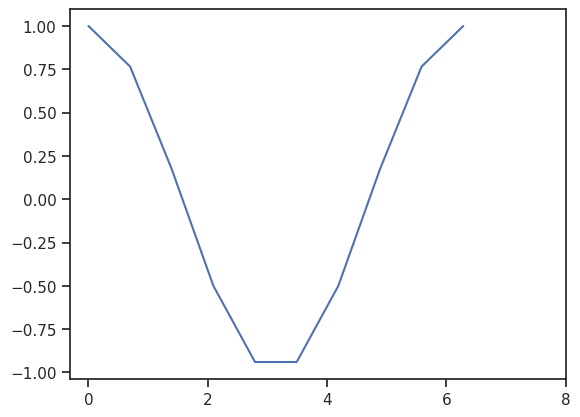

Generate + Pipeline:  54%|█████▎    | 535/1000 [11:47<05:32,  1.40it/s]<string>:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use eit

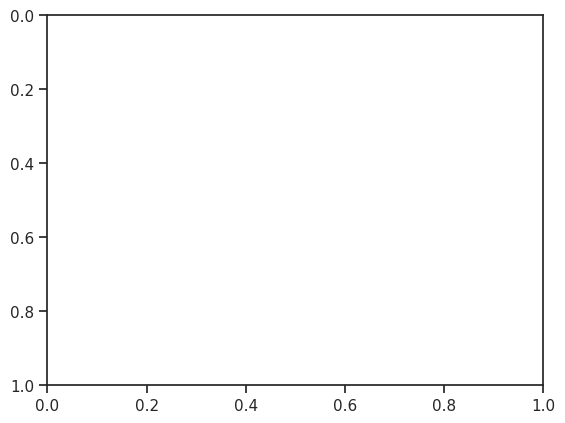

Generate + Pipeline:  56%|█████▌    | 558/1000 [12:07<05:01,  1.47it/s]

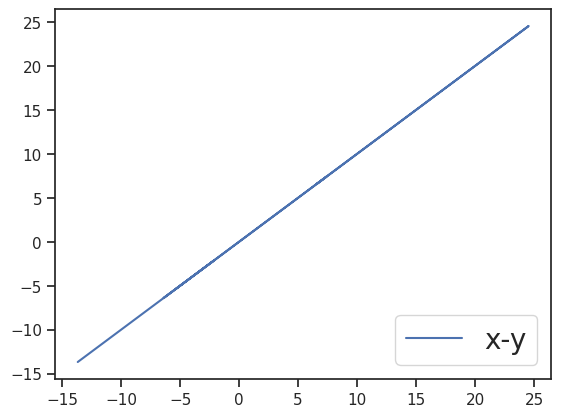

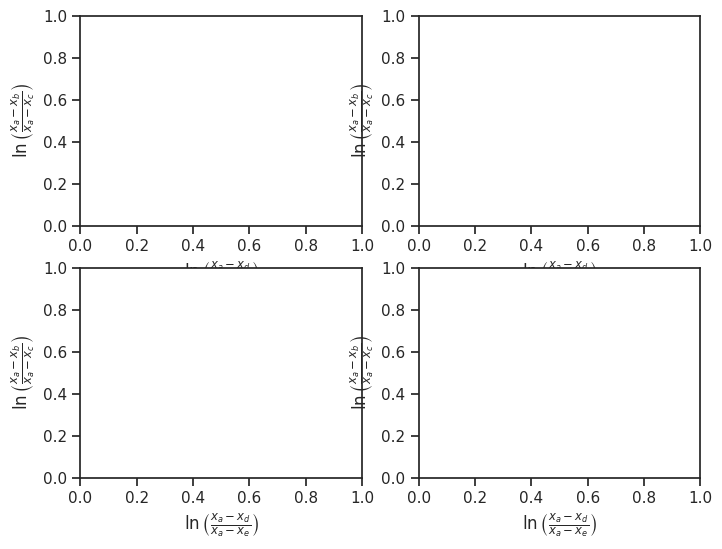

<Figure size 640x480 with 0 Axes>

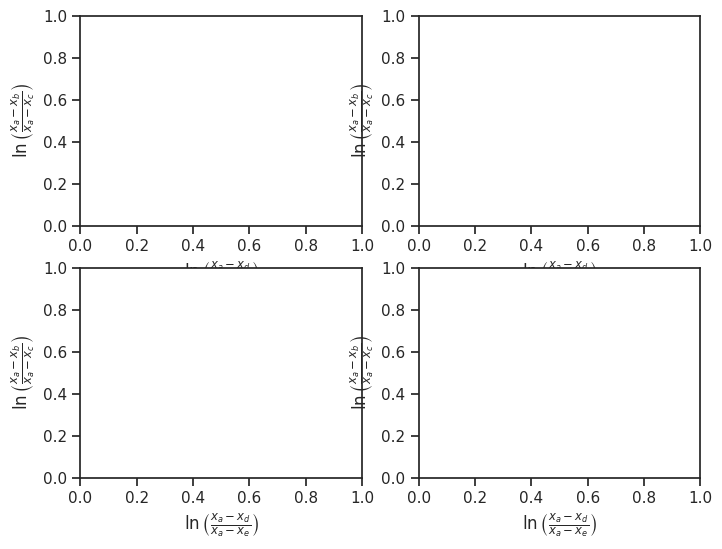

Generate + Pipeline:  56%|█████▌    | 562/1000 [12:12<07:36,  1.04s/it]

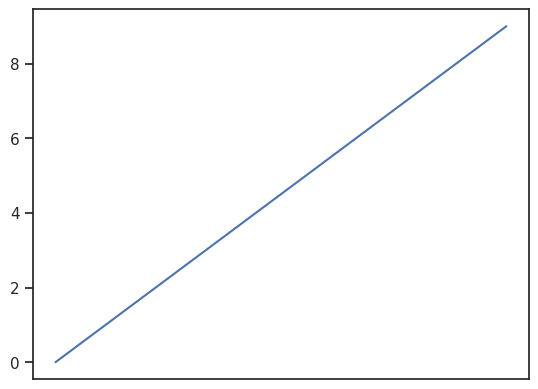

Generate + Pipeline:  57%|█████▊    | 575/1000 [12:32<11:01,  1.56s/it]

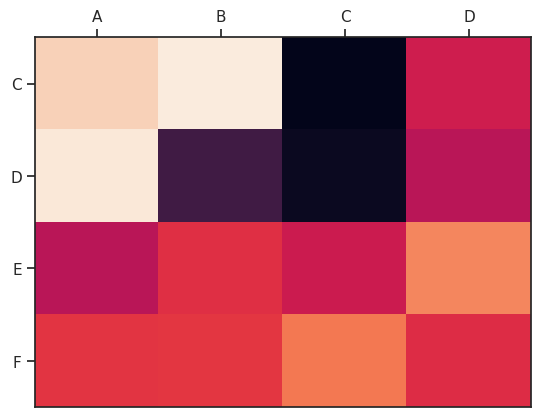

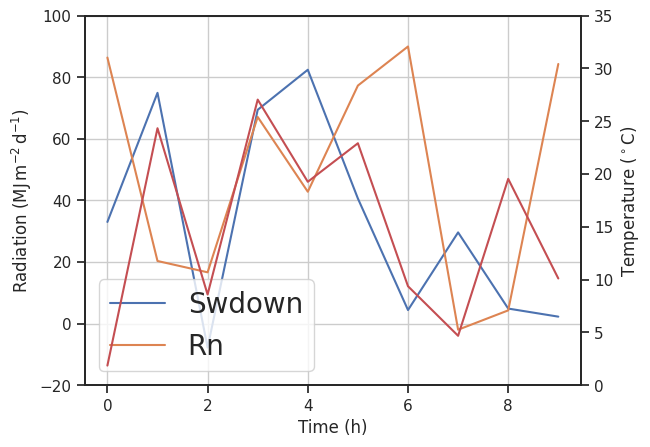

<Figure size 640x480 with 0 Axes>

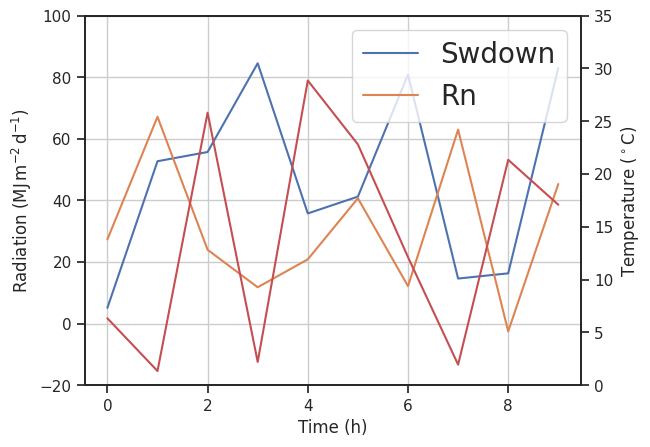

<Figure size 640x480 with 0 Axes>

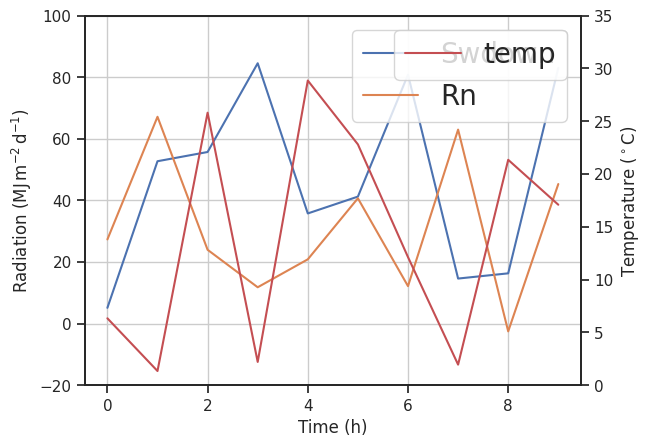

Generate + Pipeline:  59%|█████▊    | 586/1000 [12:49<08:26,  1.22s/it]

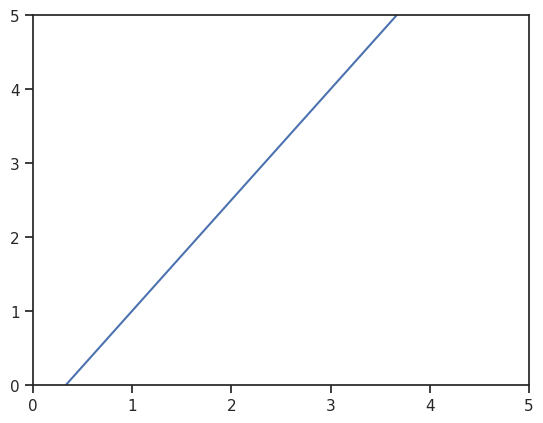

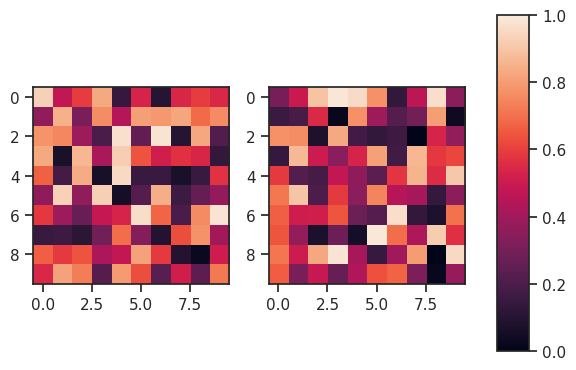

Generate + Pipeline:  59%|█████▉    | 593/1000 [13:00<09:56,  1.46s/it]

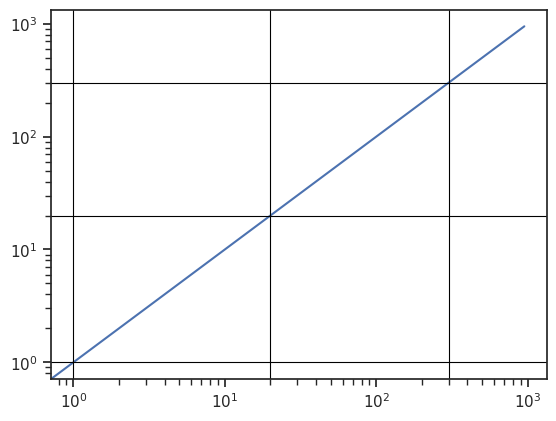

Generate + Pipeline:  60%|█████▉    | 595/1000 [13:05<11:48,  1.75s/it]

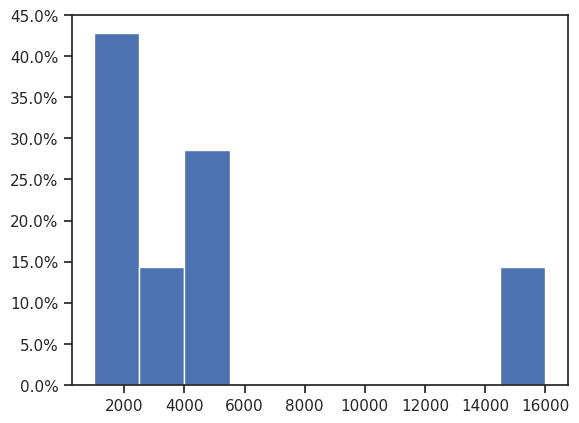

Generate + Pipeline:  62%|██████▏   | 615/1000 [13:25<05:14,  1.22it/s]

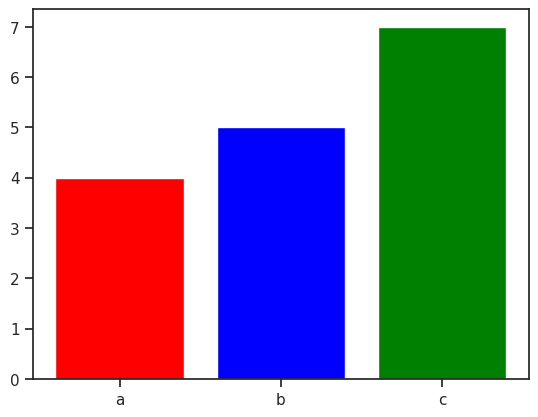

Generate + Pipeline:  62%|██████▏   | 624/1000 [13:33<05:51,  1.07it/s]<string>:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

<string>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

Generate + Pipeline:  65%|██████▌   | 653/1000 [14:09<07:14,  1.25s/it]

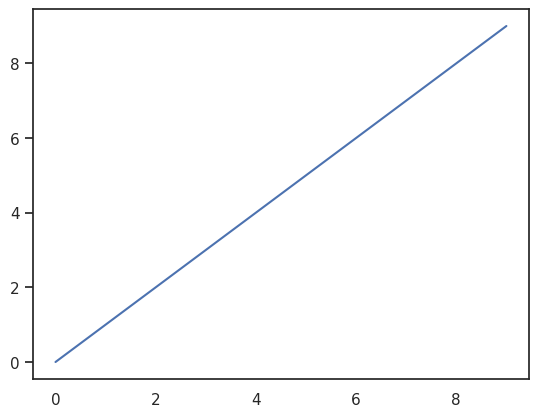

Generate + Pipeline:  66%|██████▌   | 662/1000 [14:22<06:28,  1.15s/it]/opt/conda/lib/python3.11/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
<string>:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/opt/conda/lib/python3.11/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
<string>:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
Generate + Pipeline:  67%|██████▋   | 673/1000 [14:38<06:25,  1.18s/it]I0000 00:00:1773475418.500752    2893 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1251 MB memory:  -> device: 0, name: NVIDIA RTX A4000, 

Done. 1000 pipeline results.


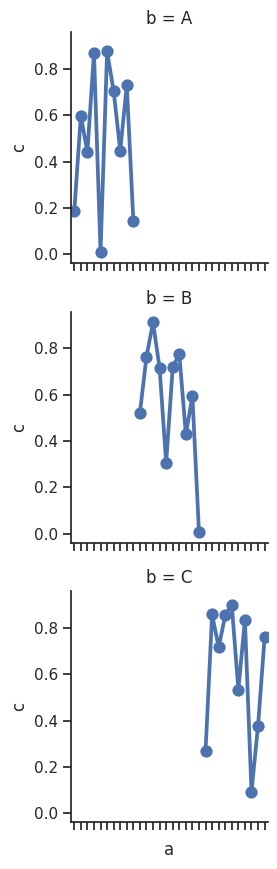

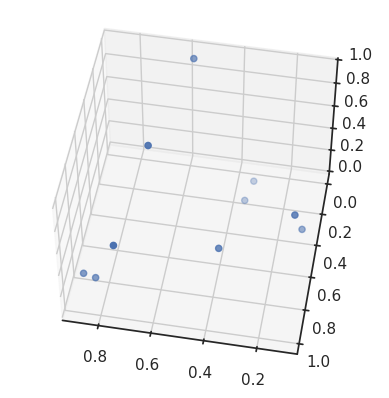

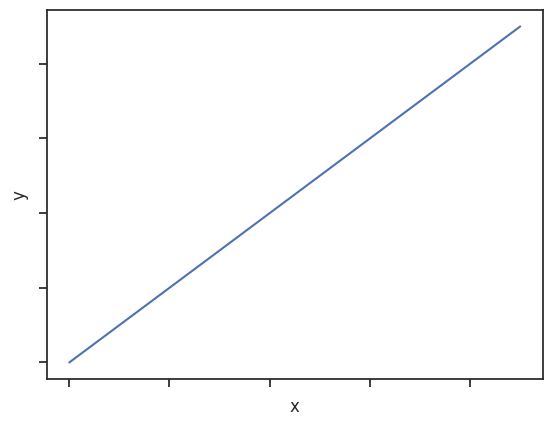

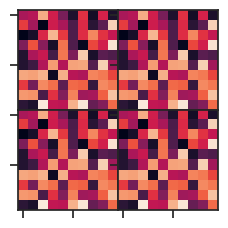

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model_device = next(model.parameters()).device
results = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Generate + Pipeline"):
    raw_prompt = row.get("prompt_2", row.get("prompt", ""))
    exec_snippet = extract_only_exec_context_wi(row.get("code_context", ""))
    formatted_messages = contruct_prompt_ds1k_v4(raw_prompt, exec_snippet)
    inputs = tokenizer.apply_chat_template(formatted_messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt")
    inputs = {k: v.to(model_device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=512, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    gen_ids = outputs[0][len(inputs["input_ids"][0]):]
    raw_response = tokenizer.decode(gen_ids, skip_special_tokens=True)
    generated_code = extract_python_code_humaneval(raw_response)
    row_dict = {"code_context": row.get("code_context", ""), "canonical_solution": row.get("reference_code", "")}
    row_dict["task_id"] = row["task_id"]
    pipeline_output = run_full_hallucination_pipeline(row_dict, "ds1000", row["task_id"], generated_code)
    results.append(pipeline_output)
print(f"Done. {len(results)} pipeline results.")

In [25]:
results_df = pd.DataFrame(results)
def serialize_col(val):
    if val is None:
        return ""
    if isinstance(val, dict):
        return str(val)
    return str(val)
results_df["ast_info"] = results_df["ast_info"].map(serialize_col)
results_df["dynamic_info"] = results_df["dynamic_info"].map(serialize_col)
results_df["lib_info"] = results_df["lib_info"].map(serialize_col)
cols = ["dataset", "task_id", "status", "ast_info", "dynamic_info", "lib_info", "generated_code", "patched_code", "error_sources", "error_types", "error_lines"]
if "canonical_solution" in results_df.columns:
    cols = cols + ["canonical_solution"]
results_df = results_df[[c for c in cols if c in results_df.columns]]
out_dir = NOTEBOOK_DIR if "NOTEBOOK_DIR" in dir() else os.getcwd()
out_path = os.path.join(out_dir, "ds1000_adapter_pipeline_output.csv")
# Windows: saves locally; no Colab download widget
results_df.to_csv(out_path, index=False)
print(f"Saved to {out_path}")

Saved to /home/jovyan/FED/DS1000/ds1000_adapter_pipeline_output.csv


## 8. Compare and optional breakdown

In [26]:
passed_sft = (results_df["status"] == "passed").sum()
total_sft = len(results_df)
pass_rate_sft = passed_sft / total_sft if total_sft else 0
print("=== Pass rate comparison ===")
print(f"Before SFT (from CSV): {pass_rate_baseline:.2%} ({passed_baseline}/{total_baseline})")
print(f"After SFT (adapters):  {pass_rate_sft:.2%} ({passed_sft}/{total_sft})")
diff = pass_rate_sft - pass_rate_baseline
print(f"Difference: {diff:+.2%}")
if pass_rate_sft > pass_rate_baseline:
    print("Conclusion: Adapter improves DS1000 pass@1.")
elif pass_rate_sft < pass_rate_baseline:
    print("Conclusion: Adapter pass rate is lower than baseline.")
else:
    print("Conclusion: Same pass rate.")

=== Pass rate comparison ===
Before SFT (from CSV): 18.10% (181/1000)
After SFT (adapters):  73.40% (734/1000)
Difference: +55.30%
Conclusion: Adapter improves DS1000 pass@1.


In [27]:
from collections import Counter
failed = results_df[results_df["status"] != "passed"]
if len(failed) > 0 and "error_types" in failed.columns:
    breakdown = failed["error_types"].value_counts()
    print("After SFT failure breakdown (error_types):")
    for et, count in breakdown.head(15).items():
        print(f"  {count:3d}: {str(et)[:60]}")
else:
    print("After SFT: no failures or no error_types column.")

After SFT failure breakdown (error_types):
  108: 
   72: IndentationError
   35: TypeError
   17: ValueError
   17: AttributeError
    5: KeyError
    3: SyntaxError
    2: ValueError,lib:attribute_error
    1: AxisError
    1: LinAlgError
    1: NotImplementedError
    1: NameError
    1: IndexError
    1: RuntimeError
    1: ModuleNotFoundError
